# Data Analysis and Visualization with Google Gemini
**Powered by open-source [Code Interpreter SDK](https://github.com/e2b-dev/code-interpreter) by [E2B](https://e2b.dev/docs)**

This example uses the E2B's [Code Interpreter](https://github.com/e2b-dev/code-interpreter) as a tool for Google's Gemini 3.0 Flash model.

We let the LLM write the code to train a machine learning model on a dataset from Kaggle. E2B's code interpreter SDK quickly creates a secure cloud sandbox powered by [Firecracker](https://github.com/firecracker-microvm/firecracker). Inside this sandbox is a running Jupyter server that the LLM can use.

### Step 1: Install dependencies

We start by installing the [E2B code interpreter SDK](https://github.com/e2b-dev/code-interpreter) and [Google's Gen AI Python SDK](https://ai.google.dev/gemini-api/docs/libraries).

In [18]:
%pip install google-genai e2b_code_interpreter python-dotenv


[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


### Step 2: Define API keys and prompt

Let's define our variables with API keys for Gemini and E2B together with the model ID and prompt.

In [19]:
import os
from dotenv import load_dotenv

load_dotenv()

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
E2B_API_KEY = os.getenv("E2B_API_KEY")
MODEL_NAME = "gemini-3.0-flash-preview"


SYSTEM_PROMPT = """
You are an expert Data Analyst and Python programmer.
You have access to a remote Python environment (E2B sandbox).
Your task is to analyze data, write Python code to perform the analysis and generate visualizations.

When asked to analyze data:
1.  Verify what files are available.
2.  Write Python code to load the data (usually pandas).
3.  Perform the request analysis.
4.  Generate charts using matplotlib or seaborn.
5.  ALWAYS save the chart as a file (e.g., 'output.png', 'chart.png').
6.  Print relevant insights to stdout.

IMPORTANT CODE OUTPUT FORMAT:
You must strictly output your Python code in the following format:
```python
# ... your code here ...
```
Do not include any other markdown code blocks or shell commands unless explicitly asked.
"""

### Step 3: Define the Code Execution tool for Gemini

We define the `execute_python` tool that Gemini will use to run code in the sandbox. Note that we use a strict schema so Gemini knows it must provide a string named code.

In [20]:
from google import genai
from google.genai import types

# Define the tool for Gemini
execute_python_tool = {
    "name": "execute_python",
    "description": "Execute python code in a Jupyter notebook cell and returns any result, stdout, stderr, display_data, and error.",
    "parameters": {
        "type": "OBJECT",
        "properties": {
            "code": {
                "type": "STRING",
                "description": "The python code to execute in a single cell."
            }
        },
        "required": ["code"]
    }
}

tools = [types.Tool(function_declarations=[execute_python_tool])]

We also define a function to extract the code from the response.

In [21]:
def extract_code(response):
    """Extracts the Python code block from the LLM response parts."""
    if not response.candidates:
        return None
        
    for part in response.candidates[0].content.parts:
        if part.text:
            match = re.search(r"```python\n(.*?)\n```", part.text, re.DOTALL)
            if match:
                return match.group(1)
    return None


### Step 4: Implement the code interpretation logic

This function sends the code to the E2B sandbox for execution and captures the results, including standard output, errors, and rich media (images).

In [22]:
def code_interpret(code_interpreter, code):
    print("Running code interpreter...")
    
    exec = code_interpreter.run_code(
        code,
        on_stderr=lambda stderr: print("[Code Interpreter]", stderr),
        on_stdout=lambda stdout: print("[Code Interpreter]", stdout)
    )
    
    if exec.error:
        print("[Code Interpreter ERROR]", exec.error)
        raise Exception(exec.error.value)
        
    return exec.results

We also define the upload_dataset function to upload the dataset to the Code Interpreter sandbox.

In [ ]:
def upload_dataset(code_interpreter):
    print('Uploading dataset to Code Interpreter sandbox...')
    dataset_path = './city_temperature.csv'
    
    if not os.path.exists(dataset_path):
        raise Exception('Dataset file not found')
    
    with open(dataset_path, 'rb') as f:
        file_buffer = f.read()
    
    try:
        remote_path = code_interpreter.files.write('city_temperature.csv', file_buffer)
        if not remote_path:
            raise Exception('Failed to upload dataset')
        return remote_path
    except Exception as error:
        print('Error during file upload:', error)
        raise error

### Initialize the Gemini Chat Session
We use client.chats.create to start a session. This session handles Thought Signatures automatically, for the Gemini 3 API

In [24]:
client = genai.Client(api_key=GEMINI_API_KEY)

chat = client.chats.create(
    model="gemini-3-flash-preview",
    config=types.GenerateContentConfig(
        system_instruction=SYSTEM_PROMPT,
        temperature=0.1
    )
)

### Step 6: Execute the analysis

Finally, we run the code. We start the sandbox, upload the dataset, and start the chat.

Uploading dataset to Code Interpreter sandbox...
Uploaded at WriteInfo(name='city_temperature.csv', type='file', path='/home/user/city_temperature.csv')

User Message: Analyze the temperature data in the city_temperature.csv file for the top 5 hottest cities globally. Create a visualization showing their average temperatures over the years.

Executing Code in E2B...
Running code interpreter...
[Code Interpreter] Top 5 Hottest Cities (Historical Average):
          City        Country  AvgTemp_C
5       Bissau  Guinea-Bissau  27.964185
10     Cotonou          Benin  27.616858
9      Conakry         Guinea  27.547362
0      Abidjan    Ivory Coast  26.914352
11  Libreville          Gabon  26.599174

[Code Interpreter] 
Visualization saved as hottest_cities_trends.png

Insights:
- Bissau: From 1995 to 2019, the average temperature changed by -0.93°C.
- Cotonou: From 1995 to 2019, the average temperature changed by +0.41°C.
- Conakry: From 1995 to 2019, the average temperature changed by +0

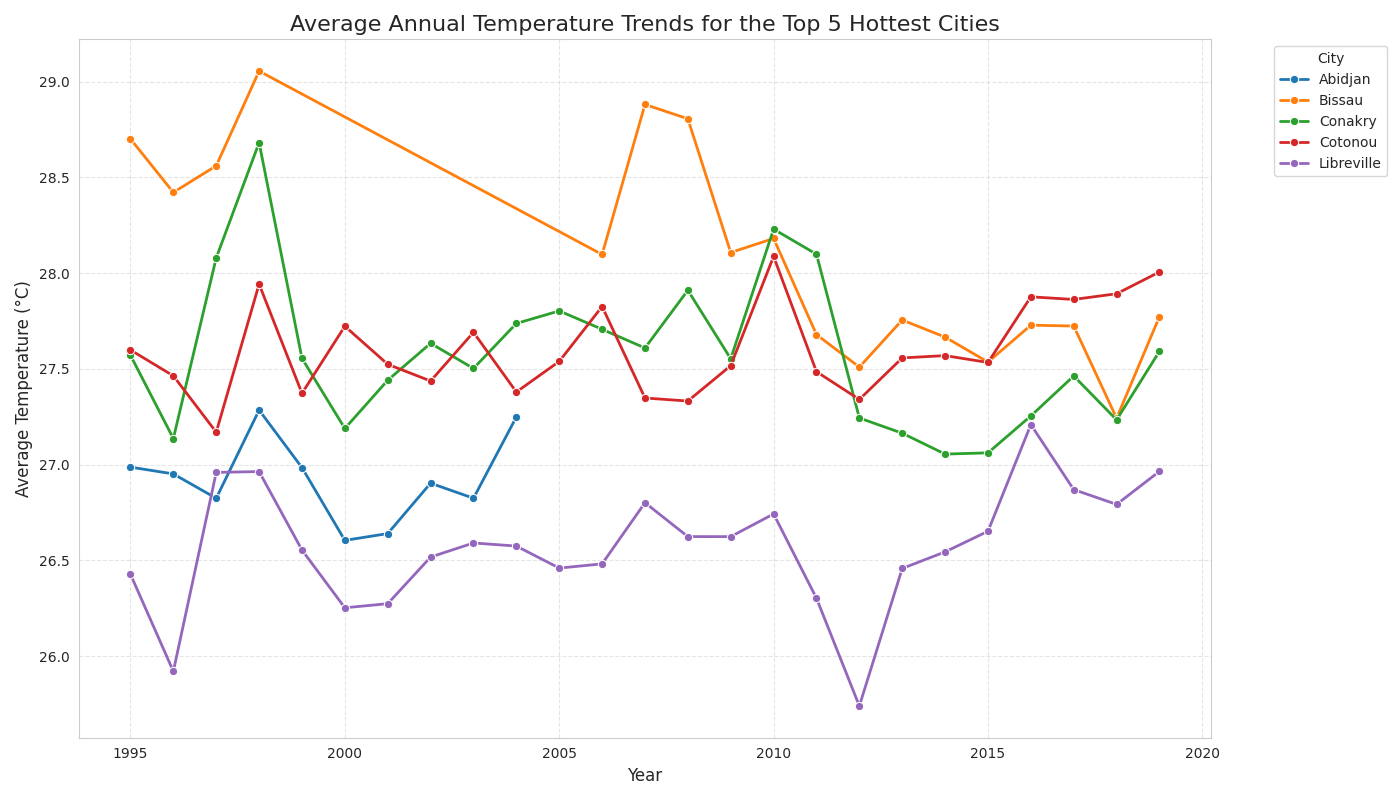

In [29]:
import base64
from IPython.display import display, Image as IPImage

# Initialize the E2B Sandbox
sandbox = Sandbox(api_key=E2B_API_KEY)

upload_dataset(sandbox)
user_query = f"Analyze the temperature data in the city_temperature.csv file for the top 5 hottest cities globally. Create a visualization showing their average temperatures over the years."

print(f"\n{'='*50}\nUser Message: {user_query}\n{'='*50}")

response = chat.send_message(user_query)

# Extract and Execute Code
code = extract_code(response)
if code:
    print("\nExecuting Code in E2B...")
    execution_results  = code_interpret(sandbox, code)

    # Check execution results for images (e2b captures plots)
    image_path = "city_temperatures.png"
    
    for i, result in enumerate(execution_results):
        if hasattr(result, 'png') and result.png:
            chart_bytes = base64.b64decode(result.png)
            with open(image_path, "wb") as f:
                f.write(chart_bytes)
            print(f"\nDownloaded generated chart from results to: {image_path}")

            display(IPImage(data=chart_bytes))
            break
    



Now we feed the plot back to Gemini to ask a reasoning question

In [31]:

print("\nSending chart back to Gemini for analysis...")

# Load image for Gemini
img = Image.open(image_path)

vision_query = "Here is the chart you generated. Does it look correct based on the data? What insights can you derive from it?"

response_v = chat.send_message([vision_query, img])

print("\nGemini Vision Analysis:")
print(response_v.text)


sandbox.kill()
print("\nSandbox closed.")


Sending chart back to Gemini for analysis...

Gemini Vision Analysis:
The chart accurately reflects the data processed from the `city_temperature.csv` file, but it also highlights some important characteristics and limitations of the dataset itself.

### 1. Correctness and Data Observations
*   **Data Gaps:** The most noticeable feature is the **missing data**. 
    *   **Abidjan (Blue):** The data cuts off after 2004, indicating no records for this city in the latter half of the dataset.
    *   **Bissau (Orange):** There is a large gap between 1998 and 2007 where the line is perfectly straight, meaning the plotting tool simply connected two distant data points because the years in between were missing.
*   **Regional Bias:** All five cities (Abidjan, Bissau, Conakry, Cotonou, and Libreville) are located in **West and Central Africa**. While these are tropical and hot, the absence of cities from the Middle East (like Kuwait or Riyadh) or the Sahara suggests that those regions might h